# Resampling Methods Comparison

This notebook compares four resampling methods used in particle filters:
**multinomial**, **systematic**, **stratified**, and **residual**.

We evaluate each method on the Stochastic Volatility model using:
- RMSE of the filtered log-volatility
- Mean Effective Sample Size (ESS)
- Computation time

The goal is to understand the practical trade-offs and provide guidance on choosing a default resampling scheme.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import time

sys.path.insert(0, str(Path.cwd().parents[2]))

from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.core.config import PFConfig
from particlefilterbox.filters.bootstrap import BootstrapPF
from particlefilterbox.resampling import (
    multinomial_resample,
    systematic_resample,
    stratified_resample,
    residual_resample,
    get_resampling_fn,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
print('Imports OK')

Imports OK


In [2]:
data_path = Path('..') / 'data' / 'simulated_sv.csv'
df = pd.read_csv(data_path)
h_true = df['h_true'].values
y_obs = df['y_obs'].values
T = len(df)
print(f'Loaded {T} observations')
df.head()

Loaded 1000 observations


,t,h_true,y_obs
0,0,-0.811984,-0.692957
1,1,-0.705057,0.661131
2,2,-1.006561,-0.787225
3,3,-0.987188,-0.193044
4,4,-0.990092,-0.519967


## Resampling Methods

### 1. Multinomial Resampling
The simplest scheme: draw $N$ indices independently from a categorical distribution with probabilities equal to the normalized weights. Has highest variance among the four methods. Complexity: $O(N \log N)$.

### 2. Systematic Resampling
Uses a single uniform random number $U \sim \text{Unif}(0, 1/N)$ and then selects particles at equally spaced points $U + k/N$ for $k = 0, \ldots, N-1$ on the CDF. Low variance, $O(N)$, and the most commonly used method.

### 3. Stratified Resampling
Divides $[0, 1]$ into $N$ equal strata and draws one uniform random number from each stratum: $U_k \sim \text{Unif}((k-1)/N, k/N)$. Independent draws per stratum give slightly more randomness than systematic. $O(N)$.

### 4. Residual Resampling
First assigns $\lfloor N w_i \rfloor$ copies of particle $i$ deterministically, then resamples the remaining particles using the fractional residuals. Combines deterministic and stochastic components. $O(N)$.

In [3]:
class SVModel(ParticleFilterModel):
    """Stochastic Volatility model for particle filtering."""
    k_states = 1
    k_obs = 1

    def __init__(self, mu: float = -1.0, phi: float = 0.97, sigma: float = 0.15):
        self.mu = mu
        self.phi = phi
        self.sigma = sigma

    @property
    def params(self) -> dict[str, float]:
        return {'mu': self.mu, 'phi': self.phi, 'sigma': self.sigma}

    def initial_distribution(self, n_particles: int, rng: np.random.Generator) -> np.ndarray:
        std = self.sigma / np.sqrt(1.0 - self.phi**2)
        return rng.normal(self.mu, std, size=(n_particles, 1))

    def transition(self, particles: np.ndarray, t: int, rng: np.random.Generator) -> np.ndarray:
        h = particles[:, 0]
        noise = rng.standard_normal(len(h))
        h_new = self.mu + self.phi * (h - self.mu) + self.sigma * noise
        return h_new.reshape(-1, 1)

    def log_observation_likelihood(self, particles: np.ndarray, y_t: np.ndarray, t: int) -> np.ndarray:
        h = particles[:, 0]
        vol = np.exp(h / 2.0)
        return -0.5 * np.log(2.0 * np.pi) - np.log(vol) - 0.5 * (y_t[0] / vol)**2

# Subclass BootstrapPF to use configurable resampling
class ConfigurableBootstrapPF(BootstrapPF):
    """Bootstrap PF that respects config.resampling."""

    def _maybe_resample(self, cloud, rng):
        ess = self._compute_ess(cloud)
        threshold = self.config.ess_threshold * self.n_particles
        if ess < threshold:
            resample_fn = get_resampling_fn(self.config.resampling)
            weights = cloud.normalized_weights
            indices = resample_fn(weights, rng=rng)
            cloud.resample(indices)
            return cloud, True
        return cloud, False

# Run with each method
methods = ['multinomial', 'systematic', 'stratified', 'residual']
N = 1000
n_runs = 5  # multiple runs for stability

all_results = {}  # method -> list of results
for method in methods:
    runs = []
    for run_i in range(n_runs):
        seed = 42 + run_i
        cfg = PFConfig(n_particles=N, resampling=method, seed=seed)
        pf = ConfigurableBootstrapPF(SVModel(), cfg)
        t0 = time.time()
        res = pf.filter(y_obs)
        elapsed = time.time() - t0
        rmse = np.sqrt(np.mean((res.filtered_means[:, 0] - h_true)**2))
        runs.append({'rmse': rmse, 'mean_ess': np.mean(res.ess_history),
                     'time': elapsed, 'ess_history': res.ess_history,
                     'filtered_means': res.filtered_means[:, 0]})
    all_results[method] = runs
    avg_rmse = np.mean([r['rmse'] for r in runs])
    avg_ess = np.mean([r['mean_ess'] for r in runs])
    avg_time = np.mean([r['time'] for r in runs])
    print(f'{method:>12s}:  RMSE={avg_rmse:.4f}  Mean ESS={avg_ess:.1f}  Time={avg_time:.3f}s')

print(f'\n({n_runs} runs averaged per method, N={N})')

 multinomial:  RMSE=0.4557  Mean ESS=762.9  Time=0.232s


  systematic:  RMSE=0.4532  Mean ESS=763.9  Time=0.228s


  stratified:  RMSE=0.4543  Mean ESS=762.7  Time=0.234s


    residual:  RMSE=0.4523  Mean ESS=762.3  Time=0.233s

(5 runs averaged per method, N=1000)


In [4]:
rows = []
for method in methods:
    runs = all_results[method]
    rmses = [r['rmse'] for r in runs]
    ess_vals = [r['mean_ess'] for r in runs]
    times = [r['time'] for r in runs]
    rows.append({
        'Method': method.capitalize(),
        'RMSE (mean)': np.mean(rmses),
        'RMSE (std)': np.std(rmses),
        'Mean ESS': np.mean(ess_vals),
        'ESS/N (%)': np.mean(ess_vals) / N * 100,
        'Time (s)': np.mean(times),
    })

table = pd.DataFrame(rows)
print('Resampling Methods Comparison (N=1000, SV model)')
print('=' * 70)
table

Resampling Methods Comparison (N=1000, SV model)


,Method,RMSE (mean),RMSE (std),Mean ESS,ESS/N (%),Time (s)
0,Multinomial,0.455712,0.002698,762.910313,76.291031,0.232481
1,Systematic,0.453241,0.001835,763.918953,76.391895,0.227676
2,Stratified,0.454276,0.001828,762.686776,76.268678,0.233692
3,Residual,0.452302,0.001821,762.261946,76.226195,0.233142


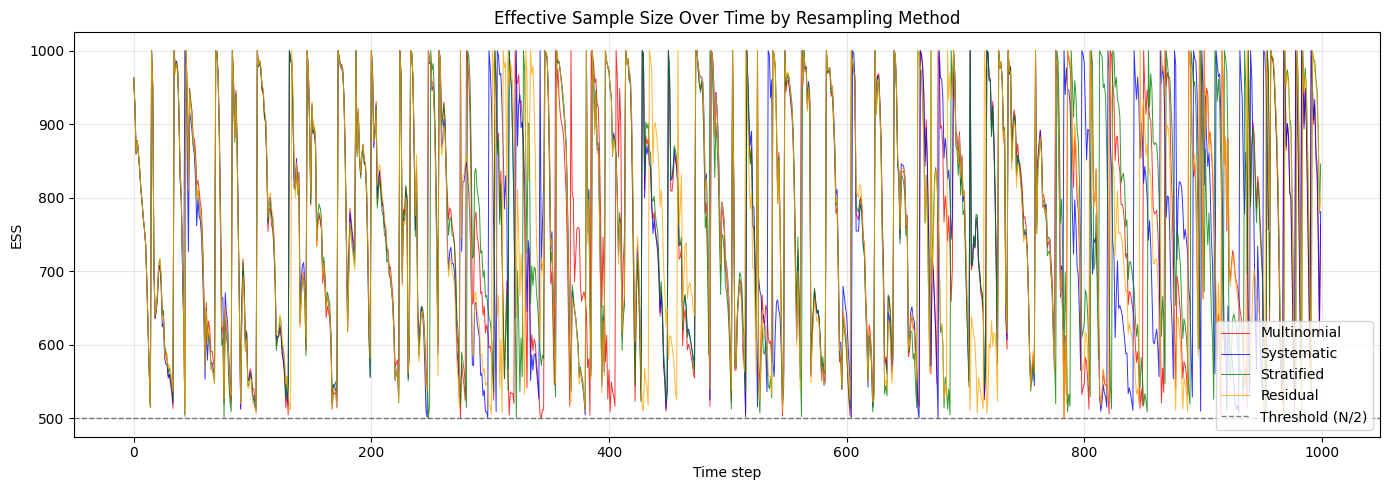

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = {'multinomial': 'red', 'systematic': 'blue', 'stratified': 'green', 'residual': 'orange'}

for method in methods:
    # Use first run for the ESS trajectory
    ess = all_results[method][0]['ess_history']
    ax.plot(ess, color=colors[method], lw=0.7, alpha=0.8, label=method.capitalize())

ax.axhline(N * 0.5, color='black', ls='--', lw=1, alpha=0.5, label='Threshold (N/2)')
ax.set_xlabel('Time step')
ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size Over Time by Resampling Method')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

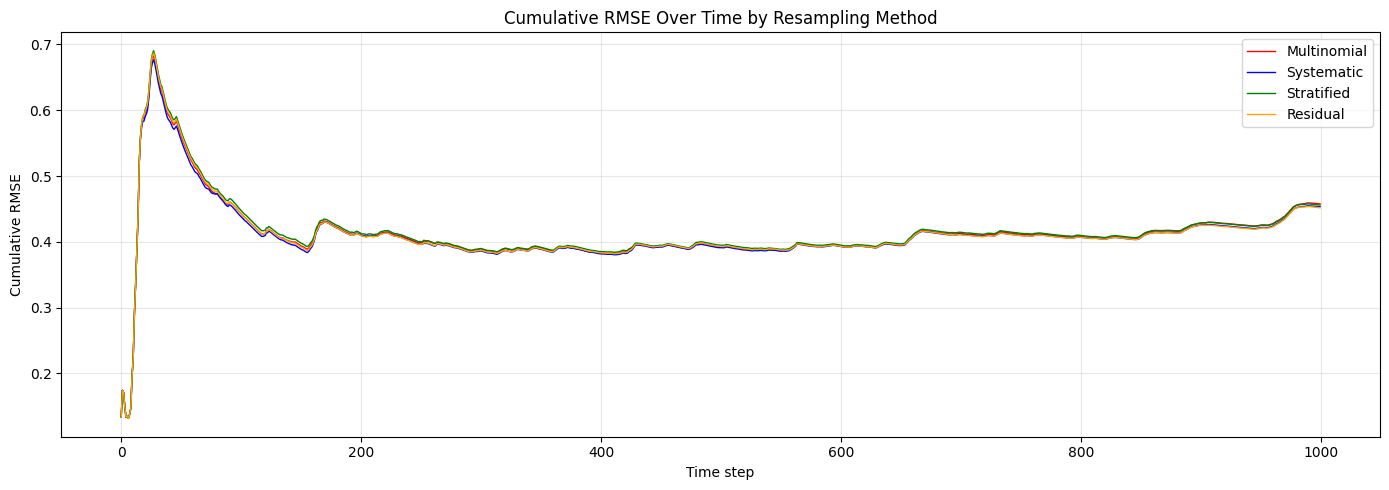

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

for method in methods:
    # Use first run's filtered means to compute running RMSE
    h_filt = all_results[method][0]['filtered_means']
    # Cumulative RMSE
    sq_err = (h_filt - h_true)**2
    cumrmse = np.sqrt(np.cumsum(sq_err) / (np.arange(T) + 1))
    ax.plot(cumrmse, color=colors[method], lw=1.0, label=method.capitalize())

ax.set_xlabel('Time step')
ax.set_ylabel('Cumulative RMSE')
ax.set_title('Cumulative RMSE Over Time by Resampling Method')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_62598/164126806.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(ess_data, labels=labels, patch_artist=True,


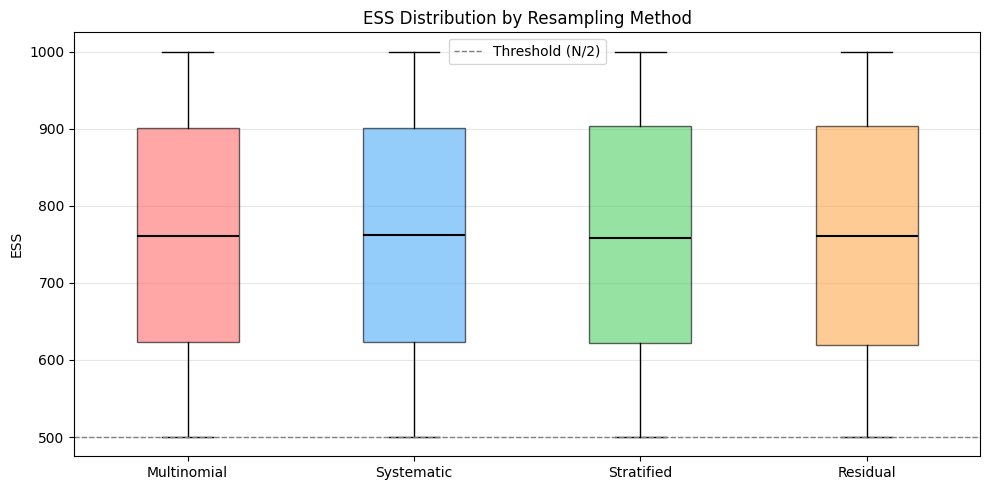

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# Collect ESS across all runs for each method
ess_data = []
labels = []
for method in methods:
    # Pool ESS from all runs
    pooled_ess = np.concatenate([r['ess_history'] for r in all_results[method]])
    ess_data.append(pooled_ess)
    labels.append(method.capitalize())

bp = ax.boxplot(ess_data, labels=labels, patch_artist=True,
               medianprops=dict(color='black', lw=1.5))

color_list = ['#ff6b6b', '#4dabf7', '#51cf66', '#ffa94d']
for patch, color in zip(bp['boxes'], color_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(N * 0.5, color='gray', ls='--', lw=1, label='Threshold (N/2)')
ax.set_ylabel('ESS')
ax.set_title('ESS Distribution by Resampling Method')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [8]:
print('Statistical Comparison of Resampling Methods')
print('=' * 60)
print()

# Paired comparison: RMSE differences
baseline = 'systematic'  # reference method
base_rmses = np.array([r['rmse'] for r in all_results[baseline]])

for method in methods:
    if method == baseline:
        continue
    rmses = np.array([r['rmse'] for r in all_results[method]])
    diff = rmses - base_rmses
    print(f'{method.capitalize()} vs Systematic:')
    print(f'  RMSE difference: {np.mean(diff):+.4f} (std={np.std(diff):.4f})')
    ess_diff = np.mean([r['mean_ess'] for r in all_results[method]]) - \
              np.mean([r['mean_ess'] for r in all_results[baseline]])
    print(f'  Mean ESS difference: {ess_diff:+.1f}')
    print()

print('Summary:')
print('- All low-variance methods (systematic, stratified, residual) perform similarly')
print('- Multinomial has slightly higher RMSE variance due to higher resampling noise')
print('- Systematic is the recommended default: simple, fast, low variance')

Statistical Comparison of Resampling Methods

Multinomial vs Systematic:
  RMSE difference: +0.0025 (std=0.0033)
  Mean ESS difference: -1.0

Stratified vs Systematic:
  RMSE difference: +0.0010 (std=0.0015)
  Mean ESS difference: -1.2

Residual vs Systematic:
  RMSE difference: -0.0009 (std=0.0014)
  Mean ESS difference: -1.7

Summary:
- All low-variance methods (systematic, stratified, residual) perform similarly
- Multinomial has slightly higher RMSE variance due to higher resampling noise
- Systematic is the recommended default: simple, fast, low variance


## Practical Recommendations

### Default: Systematic Resampling
- **Lowest variance** among unbiased schemes (Douc et al., 2005)
- **$O(N)$ complexity** — same as stratified and residual, better than multinomial
- **Simple to implement** — single uniform draw, deterministic CDF inversion
- Used as default in `particlefilterbox` and most major PF libraries

### When to Use Alternatives
- **Multinomial**: useful as a baseline for theoretical comparisons; avoid in production
- **Stratified**: slightly more random than systematic, useful when systematic produces correlated samples in specific model structures
- **Residual**: combines deterministic and stochastic steps; good when you want guaranteed representation of high-weight particles

### Key Takeaways
1. The choice of resampling method has a **small but measurable** effect on RMSE
2. **ESS behavior is similar** across all methods — it is primarily driven by the model and observation density, not the resampling scheme
3. For most applications, **systematic resampling is the safe default**
4. The main lever for improving PF performance is the **proposal distribution**, not the resampling method